# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Matías Taborda
- Alumno 2 :    -

In [5]:
import torch
# import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.datasets import fetch_lfw_people
# from sklearn.manifold import TSNE
# from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
# import os
# import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")

PyTorch: 2.11.0+cpu | Dispositivo: cpu


In [6]:
from PIL import Image
import torchvision.transforms as T

# Cargo el dataset LFW como base
lfw = fetch_lfw_people(min_faces_per_person=70, color=True, resize=1.0)

X_lfw = lfw.images    # (n_samples, 125, 94, 3) float en [0, 1]
y_lfw = lfw.target     # etiquetas numéricas
NOMBRES_LFW = lfw.target_names

print(f"Total de imágenes: {X_lfw.shape[0]}")
print(f"Tamaño de imagen: {X_lfw.shape[1:3]}")
print(f"Rango de valores: [{X_lfw.min():.2f}, {X_lfw.max():.2f}]")
print(f"\nPersonas ({len(NOMBRES_LFW)}):")

from collections import Counter
conteo = Counter(y_lfw)
for idx, nombre in enumerate(NOMBRES_LFW):
    print(f"  {nombre}: {conteo[idx]} imágenes")


# Convierto imágenes a PIL

X_lfw_pil = [Image.fromarray((img * 255).astype(np.uint8)) for img in X_lfw]

Total de imágenes: 1288
Tamaño de imagen: (125, 94)
Rango de valores: [0.00, 1.00]

Personas (7):
  Ariel Sharon: 77 imágenes
  Colin Powell: 236 imágenes
  Donald Rumsfeld: 121 imágenes
  George W Bush: 530 imágenes
  Gerhard Schroeder: 109 imágenes
  Hugo Chavez: 71 imágenes
  Tony Blair: 144 imágenes


In [7]:
# Verifico mi dataset 
from pathlib import Path
dataset_path = Path("src/data/dataset_tp1")
dataset_folders = []
total = 0
 
for folder in dataset_path.iterdir():
    if folder.is_dir():
        dataset_folders.append(folder)

# verifico imágenes en las carpetas
print("*"*20)
print("Dataset TP1")
print("*"*20)
for folder in dataset_folders:
    print(f"{folder.name}: {len(list(folder.iterdir()))} imágenes")
    total += len(list(folder.iterdir()))
print(f"Total de imágenes en el dataset: {total}")

********************
Dataset TP1
********************
persona_1: 16 imágenes
persona_2: 11 imágenes
persona_3: 13 imágenes
persona_4: 10 imágenes
persona_5: 10 imágenes
Total de imágenes en el dataset: 60


In [48]:
# Recorro las carpetas y cargo las imágenes 
X = []         
y = []
names = []

lfw_label_offset = len(NOMBRES_LFW) # a partir del índice 7

for persona_id, folder in enumerate(dataset_path.iterdir()):
    if folder.is_dir():
        names.append(folder.name)
        for img_file in folder.glob('*.jpg'):
            img = Image.open(img_file).convert('RGB')
            img = img.resize((94, 125)) # mismas dimensiones en LFW
            X.append(img) 
            y.append(persona_id + lfw_label_offset) 
 

print(f"Dataset: {len(X)} imágenes, {len(names)} personas")

Dataset: 60 imágenes, 5 personas


In [51]:
if len(X) > 0:
    # datasets combinados
    X_combined = X_lfw_pil + X
    y_combined = list(y_lfw) + y
    combined_names = list(NOMBRES_LFW) + names
    print(f"Dataset obtenido: {len(X_combined)} imágenes | {len(combined_names)} personas")
else:
    print("Dataset vacío")

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),  # PIL -> Tensor
])

class FaceDataset(torch.utils.data.Dataset):
    def __init__(self, images_pil, labels, transform=None):
        self.images = images_pil
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

combined_dataset = FaceDataset(X_combined, y_combined, transform=transform)


Dataset obtenido: 1348 imágenes | 12 personas


In [102]:
from sklearn.model_selection import train_test_split

indices_por_clase = {}
for idx, label in enumerate(y_combined):
    if label not in indices_por_clase:
        indices_por_clase[label] = []
    indices_por_clase[label].append(idx)

train_indices = []
val_indices = []

for label, indices in indices_por_clase.items():
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_indices.extend(train_idx)
    val_indices.extend(val_idx)
 
train_dataset = torch.utils.data.Subset(combined_dataset, train_indices)
val_dataset = torch.utils.data.Subset(combined_dataset, val_indices)
 
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)

train_labels = [y_combined[i] for i in train_indices]
val_labels = [y_combined[i] for i in val_indices]

print("Training set - dataset propio")
for i, name in enumerate(combined_names):
    if name.startswith('persona_'):
        count = train_labels.count(i)
        print(f"  {name}: {count} imágenes")

print(f"Train: {len(train_dataset)} imágenes")
print(f"Val: {len(val_dataset)} imágenes")
print(f"Clases: {len(combined_names)}")

Training set - dataset propio
  persona_1: 12 imágenes
  persona_2: 8 imágenes
  persona_3: 10 imágenes
  persona_4: 8 imágenes
  persona_5: 8 imágenes
Train: 1073 imágenes
Val: 275 imágenes
Clases: 12


In [90]:
import torch.nn as nn
from torchvision.models import ResNet18_Weights

# Cargo ResNet18 pre-entrenado
modelo_ft = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
 
print("Cabeza original de ResNet18 (ImageNet):")
print(f"  avgpool: {modelo_ft.avgpool}")
print(f"  fc:      {modelo_ft.fc}   → 1000 clases ImageNet")

# Reemplazo la cabeza para combined_dataset (12 clases)
NUM_CLASES = 12
DIM_FEATURES = modelo_ft.fc.in_features   # 512 para ResNet18
modelo_ft.fc = nn.Linear(DIM_FEATURES, NUM_CLASES)
modelo_ft = modelo_ft.to(device)
 
print(f"\nNueva cabeza para combined_dataset:")
print(f"  fc: {modelo_ft.fc}   → {NUM_CLASES} clases")
 
# Parámetros totales vs entrenables
total_p    = sum(p.numel() for p in modelo_ft.parameters())
train_p    = sum(p.numel() for p in modelo_ft.parameters() if p.requires_grad)
print(f"\nParámetros totales:      {total_p:,}")
print(f"Parámetros entrenables:  {train_p:,}")

Cabeza original de ResNet18 (ImageNet):
  avgpool: AdaptiveAvgPool2d(output_size=(1, 1))
  fc:      Linear(in_features=512, out_features=1000, bias=True)   → 1000 clases ImageNet

Nueva cabeza para combined_dataset:
  fc: Linear(in_features=512, out_features=12, bias=True)   → 12 clases

Parámetros totales:      11,182,668
Parámetros entrenables:  11,182,668


In [91]:
def entrenar_epoca(modelo, loader, criterion, optimizer):
    modelo.train()
    total_loss, correctas, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = modelo(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correctas += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, 100 * correctas / total

def evaluar(modelo, loader, criterion):
    modelo.eval()
    total_loss, correctas, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = modelo(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            correctas += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, 100 * correctas / total

criterion = nn.CrossEntropyLoss()

In [93]:
# Reiniciamos el modelo y congelamos el backbone
modelo_fe = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in modelo_fe.parameters():
    param.requires_grad = False

modelo_fe.fc = nn.Linear(DIM_FEATURES, NUM_CLASES) 
modelo_fe = modelo_fe.to(device)

n_train = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in modelo_fe.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)")

optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, modelo_fe.parameters()), lr=1e-3)

hist_fe = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FE = 5

Parámetros entrenables: 6,156 / 11,182,668  (0.1%)


In [ ]:
print(f"\nEntrenando {N_EPOCHS_FE} épocas (Feature Extraction)...")
for ep in range(1, N_EPOCHS_FE + 1):
    tr_l, tr_a = entrenar_epoca(modelo_fe, train_loader, criterion, optimizer_fe)
    vl_l, vl_a = evaluar(modelo_fe, val_loader, criterion)
    hist_fe["train_loss"].append(tr_l); hist_fe["train_acc"].append(tr_a)
    hist_fe["val_loss"].append(vl_l);   hist_fe["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FE}  |  train loss {tr_l:.4f}  acc {tr_a:.1f}%  "
          f"|  val loss {vl_l:.4f}  acc {vl_a:.1f}%")


##########################################
# Resultado con 5 épocas:
'''
Parámetros entrenables: 6,156 / 11,182,668  (0.1%)

Entrenando 5 épocas (Feature Extraction)...
  Época 1/5  |  train loss 1.7299  acc 44.8%  |  val loss 1.4121  acc 60.0%
  Época 2/5  |  train loss 1.2523  acc 60.7%  |  val loss 1.1630  acc 58.5%
  Época 3/5  |  train loss 1.0458  acc 66.4%  |  val loss 0.9467  acc 69.8%
  Época 4/5  |  train loss 0.9163  acc 70.6%  |  val loss 0.8690  acc 70.9%
  Época 5/5  |  train loss 0.7850  acc 77.5%  |  val loss 0.7622  acc 77.8%
'''
# Vemos que todavía hay margen de mejora, aplico fine-tuning


Entrenando 5 épocas (Feature Extraction)...
  Época 1/5  |  train loss 1.7299  acc 44.8%  |  val loss 1.4121  acc 60.0%
  Época 2/5  |  train loss 1.2523  acc 60.7%  |  val loss 1.1630  acc 58.5%
  Época 3/5  |  train loss 1.0458  acc 66.4%  |  val loss 0.9467  acc 69.8%
  Época 4/5  |  train loss 0.9163  acc 70.6%  |  val loss 0.8690  acc 70.9%
  Época 5/5  |  train loss 0.7850  acc 77.5%  |  val loss 0.7622  acc 77.8%


'\nParámetros entrenables: 6,156 / 11,182,668  (0.1%)\n\nEntrenando 5 épocas (Feature Extraction)...\n  Época 1/5  |  train loss 1.6207  acc 45.5%  |  val loss 1.2880  acc 58.1%\n  Época 2/5  |  train loss 1.2494  acc 57.5%  |  val loss 1.0647  acc 63.3%\n  Época 3/5  |  train loss 1.0567  acc 65.4%  |  val loss 0.8796  acc 73.0%\n  Época 4/5  |  train loss 0.9502  acc 68.6%  |  val loss 0.7954  acc 72.6%\n  Época 5/5  |  train loss 0.8200  acc 74.2%  |  val loss 0.7415  acc 75.2%\n'

In [96]:
# Continuo con fine-tuning sobre el modelo entrenado

for param in modelo_fe.parameters():
    param.requires_grad = True

# Dos grupos de parámetros con distintas LR (backbone lento, cabeza rápida)
params_backbone = [p for name, p in modelo_fe.named_parameters() if "fc" not in name]
params_cabeza   = list(modelo_fe.fc.parameters())


optimizer_ft = optim.Adam([
    {"params": params_backbone, "lr": 1e-6},   # LR baja para backbone
    {"params": params_cabeza,   "lr": 1e-4},   # LR algo más baja que antes para cabeza
])

n_train = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in modelo_fe.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)")

hist_ft = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FT = 10

Parámetros entrenables: 11,182,668 / 11,182,668  (100.0%)


In [97]:
print(f"Entrenando {N_EPOCHS_FT} épocas (Fine-Tuning completo)...")
for ep in range(1, N_EPOCHS_FT + 1):
    tr_l, tr_a = entrenar_epoca(modelo_fe, train_loader, criterion, optimizer_ft)
    vl_l, vl_a = evaluar(modelo_fe, val_loader, criterion)
    hist_ft["train_loss"].append(tr_l); hist_ft["train_acc"].append(tr_a)
    hist_ft["val_loss"].append(vl_l);   hist_ft["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FT} | train loss {tr_l:.4f} acc {tr_a:.1f}% | val loss {vl_l:.4f} acc {vl_a:.1f}%")

Entrenando 10 épocas (Fine-Tuning completo)...
  Época 1/10 | train loss 0.6776 acc 82.9% | val loss 0.6822 acc 80.4%
  Época 2/10 | train loss 0.5822 acc 85.6% | val loss 0.6159 acc 83.6%
  Época 3/10 | train loss 0.5307 acc 87.3% | val loss 0.5832 acc 84.7%
  Época 4/10 | train loss 0.4547 acc 91.5% | val loss 0.5319 acc 85.1%
  Época 5/10 | train loss 0.4186 acc 91.1% | val loss 0.5201 acc 86.2%
  Época 6/10 | train loss 0.3970 acc 91.7% | val loss 0.4830 acc 86.9%
  Época 7/10 | train loss 0.3495 acc 94.0% | val loss 0.4707 acc 86.5%
  Época 8/10 | train loss 0.3289 acc 94.1% | val loss 0.4170 acc 89.8%
  Época 9/10 | train loss 0.3111 acc 94.1% | val loss 0.4344 acc 86.9%
  Época 10/10 | train loss 0.2743 acc 95.6% | val loss 0.4054 acc 90.2%


In [98]:
# Guardo el mejor modelo
import os
os.makedirs("models", exist_ok=True)

torch.save({
    'modelo_state_dict': modelo_ft.state_dict(),
    'optimizer_state_dict': optimizer_ft.state_dict(),
    'hist_ft2': hist_ft,
    'hist_fe': hist_fe,
    'combined_names': combined_names,
    'NUM_CLASES': NUM_CLASES,
    'DIM_FEATURES': DIM_FEATURES
}, 'models/resnet18_facial_recognition.pth')

print("✓ Modelo guardado en models/resnet18_facial_recognition.pth")
print(f"  - Parámetros: {sum(p.numel() for p in modelo_ft.parameters()):,}")
print(f"  - Clases: {NUM_CLASES}")
print(f"  - Accuracy final: {hist_ft['val_acc'][-1]:.1f}%")

✓ Modelo guardado en models/resnet18_facial_recognition.pth
  - Parámetros: 11,182,668
  - Clases: 12
  - Accuracy final: 90.2%


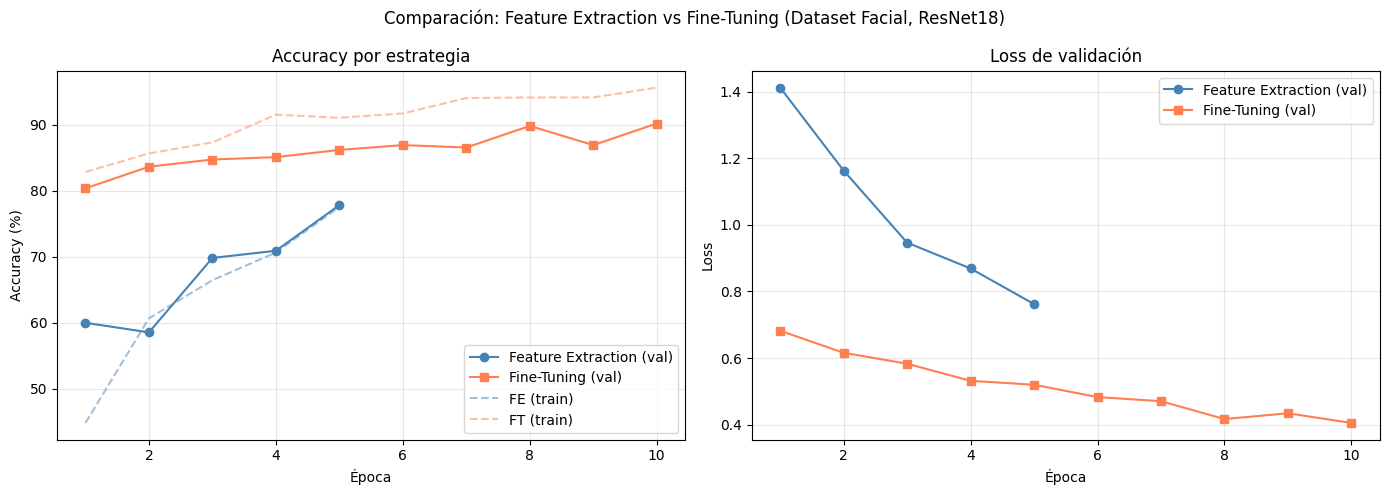


Resumen final:
  Feature Extraction: val acc = 77.8%
  Fine-Tuning:        val acc = 90.2%
  Mejora:             12.4 puntos porcentuales


In [99]:
import matplotlib.pyplot as plt

# Comparación Feature Extraction vs Fine-Tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas_fe = range(1, len(hist_fe["val_acc"]) + 1)
epocas_ft = range(1, len(hist_ft["val_acc"]) + 1)

# Accuracy
ax = axes[0]
ax.plot(epocas_fe, hist_fe["val_acc"],  "o-", color="steelblue",  label="Feature Extraction (val)")
ax.plot(epocas_ft, hist_ft["val_acc"], "s-", color="coral",      label="Fine-Tuning (val)")
ax.plot(epocas_fe, hist_fe["train_acc"], "--", color="steelblue",  alpha=0.5, label="FE (train)")
ax.plot(epocas_ft, hist_ft["train_acc"],"--", color="coral",      alpha=0.5, label="FT (train)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy por estrategia"); ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epocas_fe, hist_fe["val_loss"],   "o-", color="steelblue", label="Feature Extraction (val)")
ax.plot(epocas_ft, hist_ft["val_loss"],  "s-", color="coral",     label="Fine-Tuning (val)")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Loss de validación"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Comparación: Feature Extraction vs Fine-Tuning (Dataset Facial, ResNet18)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nResumen final:")
print(f"  Feature Extraction: val acc = {hist_fe['val_acc'][-1]:.1f}%")
print(f"  Fine-Tuning:        val acc = {hist_ft['val_acc'][-1]:.1f}%")
print(f"  Mejora:             {hist_ft['val_acc'][-1] - hist_fe['val_acc'][-1]:.1f} puntos porcentuales")

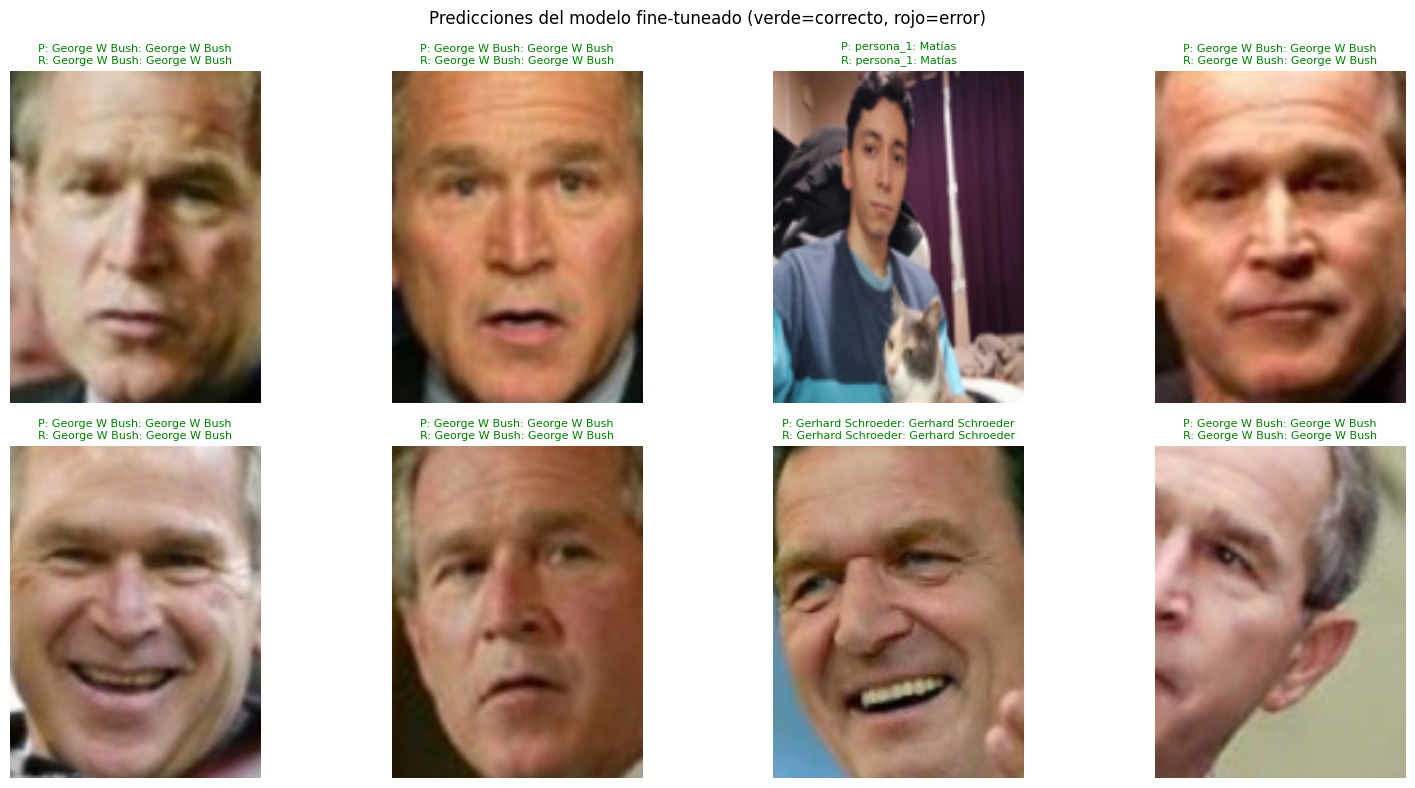

In [126]:
mapeo_nombres = {
    "persona_1": "Matías",
    "persona_2": "Agustina",
    "persona_3": "Isabel",
    "persona_4": "Vicky",
    "persona_5": "Guillermo",
}

# Inferencia - visualizando predicciones del modelo fine-tuneado
modelo_fe.eval()
imgs_batch, labels_batch = next(iter(val_loader))
imgs_batch = imgs_batch.to(device)

with torch.no_grad():
    logits = modelo_fe(imgs_batch)
    probs  = torch.softmax(logits, dim=1)

preds = probs.argmax(1).cpu()

# Visualizamos predicciones
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs_batch):
        break
    img = imgs_batch[i].cpu().permute(1, 2, 0).numpy()

    gen_pred = combined_names[preds[i].item()]
    gen_real = combined_names[labels_batch[i].item()]
    
    nombre_pred = mapeo_nombres.get(gen_pred, gen_pred)
    nombre_real = mapeo_nombres.get(gen_real, gen_real)

    pred  = preds[i].item()
    real  = labels_batch[i].item()
    color = "green" if pred == real else "red"
    ax.imshow(img)

    ax.set_title(f"P: {gen_pred}: {nombre_pred}\nR: {gen_real}: {nombre_real}", 
                 fontsize=8, color=color)
    ax.axis("off")
    
plt.suptitle("Predicciones del modelo fine-tuneado (verde=correcto, rojo=error)", fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# Pipeline: detecta rostro -> lo alinea -> extrae embedding

def detect_faces(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    return faces

def align_face(image, face_coords):
    x, y, w, h = face_coords
    face_img = image[y:y+h, x:x+w]
    return face_img

def extract_embedding(face_image, model, transform):
    model.eval()
    with torch.no_grad():
        img_tensor = transform(face_image).unsqueeze(0).to(device)
        features = model.avgpool(model.layer4(model.layer3(model.layer2(model.layer1(model.maxpool(model.relu(model.bn1(img_tensor))))))))
        features = torch.flatten(features, 1)
        return features.cpu().numpy()